In [1]:
!unzip SVD-share.zip

Archive:  SVD-share.zip
  inflating: SVD-share.ipynb         
  inflating: building.jpg            
  inflating: __MACOSX/._building.jpg  


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
## Using entire image

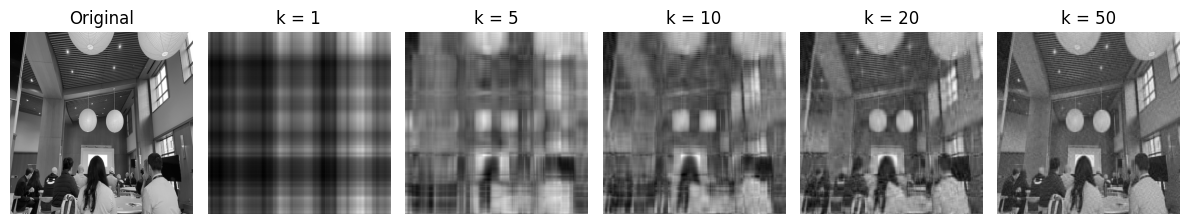

In [10]:
def svd_blur(image_path, k_values=[5, 20, 50, 100]):
    img = Image.open("Berkley_conference_image.jpg").convert('L')  # 'L' = grayscale
    A = np.array(img, dtype=np.float64) 

     # Apply SVD
    U, S, VT = np.linalg.svd(A, full_matrices=False)

    # Plot original
    plt.figure(figsize=(12, 3))
    plt.subplot(1, len(k_values)+1, 1)
    plt.imshow(A, cmap='gray')
    plt.title('Original')
    plt.axis('off')

    # Reconstruct with different k
    for idx, k in enumerate(k_values, start=2):
        Ak = U[:, :k] @ np.diag(S[:k]) @ VT[:k, :]
        plt.subplot(1, len(k_values)+1, idx)
        plt.imshow(Ak, cmap='gray')
        plt.title(f'k = {k}')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Example usage
svd_blur('Berkley_conference_image.jpg', k_values=[1, 5, 10, 20, 50])


In [11]:
## Partition & Compression Ratios 

Compression Ratios
k = 1 -> 3.76
k = 2 -> 1.88
k = 3 -> 1.25
k = 4 -> 0.94
k = 5 -> 0.75
k = 6 -> 0.63
k = 7 -> 0.54
k = 8 -> 0.47


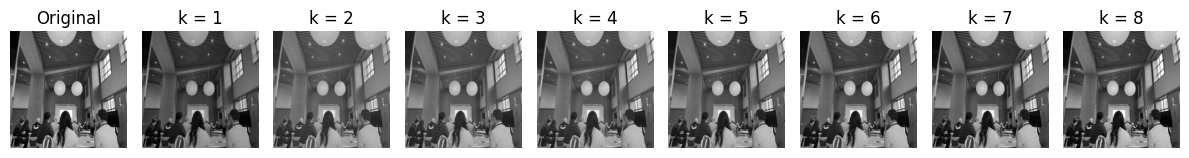

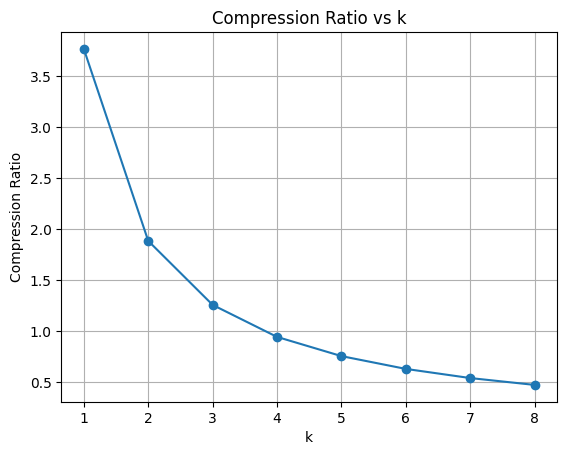

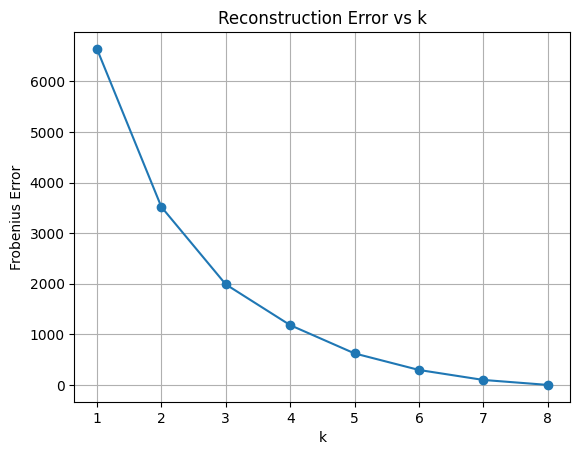

In [37]:
def compress_block(block, k):

    U, S, VT = np.linalg.svd(block, full_matrices=False)

    U_k = U[:, :k]
    S_k = np.diag(S[:k])
    VT_k = VT[:k, :]

    block_recon = U_k @ S_k @ VT_k

    return block_recon


def svd_partition_blur(image_path, k_values=[1,2,3,4,5], block_size=8):

    img = Image.open(image_path).convert('L')
    A = np.array(img, dtype=np.float64)

    h, w = A.shape

    print("Compression Ratios")
    for k in k_values:
        CR = 64/(17*k)
        print(f"k = {k} -> {CR:.2f}")

    plt.figure(figsize=(12,3))
    plt.subplot(1, len(k_values)+1, 1)
    plt.imshow(A, cmap='gray')
    plt.title("Original")
    plt.axis('off')

    k_vals = []
    compression_ratios = []
    errors = []

    for idx, k in enumerate(k_values, start=2):

        recon = np.zeros_like(A)

        for i in range(0, h, block_size):
            for j in range(0, w, block_size):

                block = A[i:i+block_size, j:j+block_size]
                block_recon = compress_block(block, k)

                recon[i:i+block_size, j:j+block_size] = block_recon

        # store metrics
        k_vals.append(k)
        compression_ratios.append(64/(17*k))

        error = np.linalg.norm(A - recon, 'fro')
        errors.append(error)

        # plot reconstruction
        plt.subplot(1, len(k_values)+1, idx)
        plt.imshow(recon, cmap='gray')
        plt.title(f"k = {k}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

    #plot_1
    plt.figure()
    plt.plot(k_vals, compression_ratios, marker='o')
    plt.xlabel("k")
    plt.ylabel("Compression Ratio")
    plt.title("Compression Ratio vs k")
    plt.grid(True)
    plt.show()

    #plot_2
    plt.figure()
    plt.plot(k_vals, errors, marker='o')
    plt.xlabel("k")
    plt.ylabel("Frobenius Error")
    plt.title("Reconstruction Error vs k")
    plt.grid(True)
    plt.show()

svd_partition_blur("Berkley_conference_image.jpg", k_values=[1,2,3,4,5,6,7,8])